2026-01-07 11-20-29
Outputs will be written to: results/run_2026-01-07 11-20-29
Saved a copy of the config : results/run_2026-01-07 11-20-29/config_copy.yaml
Inputs shape: (25, 3)
Outputs shape: (25,)
First 20 rows of raw data:
    compound-1  compound-2  compound-3  trans-side-effect  source
18    0.448900    0.470829    0.414315          -0.020404  week-4
23    0.450000    0.470000    0.400000          -0.029032  week-9
16    0.303031    0.242424    0.474748          -0.030680  week-2
3     0.492581    0.611593    0.340176          -0.034835    file
13    0.600097    0.725136    0.066089          -0.036378    file
22    0.394576    0.615328    0.367214          -0.037692  week-8
10    0.220549    0.297825    0.343555          -0.046947    file
4     0.134622    0.219917    0.458206          -0.048008    file
17    0.263346    0.138532    0.363743          -0.048179  week-3
14    0.965995    0.861120    0.566829          -0.056758    file
1     0.242114    0.644074    0.272433        

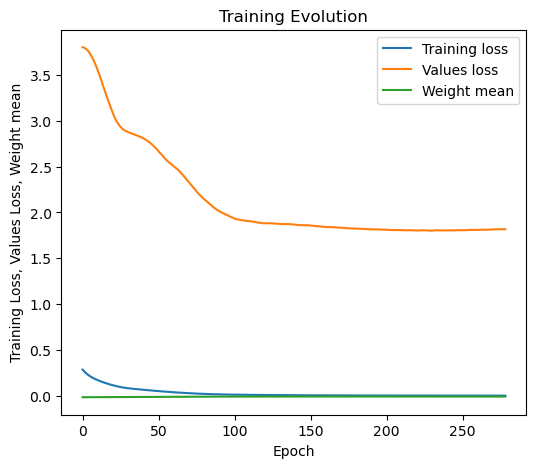

Using 3 dimensions, grid size per axis: 400, downsample: True, stride: 2
Points before downsampling: 64000000
Points after downsampling: 8000000
Final grid shape: (8000000, 3)
sample_strategy=cartesian, Final sample shape: (8000000, 3)
⚠️ No filtering applied to candidate grid
Total number of points to evaluate: 6
{'method': 'PI', 'xi': 0.1, 'kappa': None, 'x': array([0.33817885, 0.38821483, 0.45779048]), 'score': 0.4060263921231886, 'dim': 3, 'predicted_y': -0.010710749}
{'method': 'PI', 'xi': 0.2, 'kappa': None, 'x': array([1.06334825, 1.1333545 , 0.01      ]), 'score': 0.34461603517457373, 'dim': 3, 'predicted_y': -0.0274914}
{'method': 'EI', 'xi': 0.1, 'kappa': None, 'x': array([1.06334825, 1.1333545 , 0.01      ]), 'score': 0.18038204075612946, 'dim': 3, 'predicted_y': -0.0274914}
{'method': 'EI', 'xi': 0.2, 'kappa': None, 'x': array([1.06334825, 1.1333545 , 0.01      ]), 'score': 0.14289212827140502, 'dim': 3, 'predicted_y': -0.0274914}
{'method': 'UCB', 'xi': None, 'kappa': 1.0,

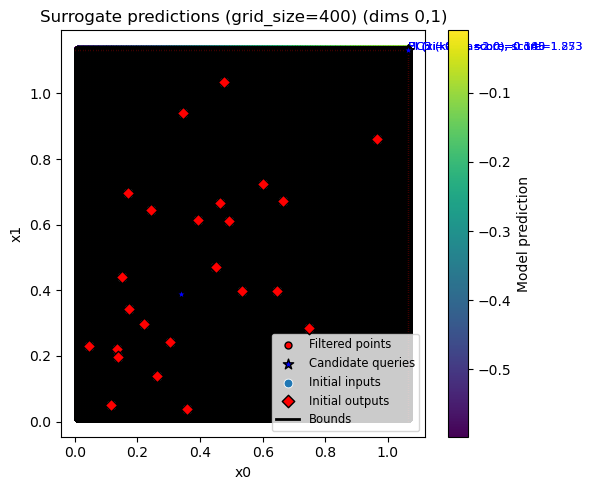

Saved dataframe to: results/run_2026-01-07 11-20-29/df_grid_400_stride2_None_max_raw_lr0.001_ep500.csv
Best candidate: {'method': 'UCB', 'xi': None, 'kappa': 2.0, 'x': array([1.06334825, 1.1333545 , 0.01      ]), 'score': 1.8733140313793277, 'dim': 3, 'predicted_y': -0.0274914}
    compound-1  compound-2  compound-3  trans-side-effect   source  trans-side-effect-scaled
0     1.063348    1.133355    0.010000           1.873314   week-x                 10.000000
1     1.063348    1.133355    0.010000           1.253322   week-x                  6.690401
2     0.338179    0.388215    0.457790           0.406026   week-x                  2.167423
3     1.063348    1.133355    0.010000           0.344616   week-x                  1.839606
4     1.063348    1.133355    0.010000           0.180382   week-x                  0.962903
5     1.063348    1.133355    0.010000           0.142892   week-x                  0.762777
6     0.448900    0.470829    0.414315          -0.020404   week-4    

In [1]:
%matplotlib inline

import sys, os
from pathlib import Path
import matplotlib as mpl

# Ensure parent folder (where run_function.py lives) is on sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

# Now you can import run_function
from run_function import load_config, instantiate_data_handler, setup_results_logging, run_pipeline, enable_full_df_print, disable_full_df_print, force_text_repr
force_text_repr()  # show all rows/cols

# Load config from the same folder as the notebook
cfg_path = Path.cwd() / "config.yaml"
cfg = load_config(cfg_path)

# set up logging to file
out_dir = setup_results_logging(cfg)

# Apply plotting overrides if present
plot_cfg = cfg.get("plot", {})
mpl.rcParams["figure.figsize"] = tuple(plot_cfg.get("figsize", (12, 8)))

# Instantiate data handler
dh = instantiate_data_handler(cfg["data_module"], cfg["data_class"])
dh.add_weekly_updates()  # ensure weekly points are merged
# 👉 Add inspection here to see the raw loaded data
print("Inputs shape:", dh.inputs.shape)
print("Outputs shape:", dh.outputs.shape)

df_raw = dh.build_dataframe()
print("First 20 rows of raw data:")
print(df_raw.head(20))

# Run pipeline inline (plots will render in notebook)
results = run_pipeline(cfg, dh, out_dir=out_dir)

print("Pipeline finished. Results keys:", list(results.keys()))